# Level 2: K-Means Clustering

## Learning Objectives
- Understand what clustering is and why it's useful
- Standardize data using StandardScaler before clustering
- Use the Elbow Method to find the best number of clusters
- Train a K-Means model and assign cluster labels
- Visualize and describe the characteristics of each cluster

---

## What is K-Means Clustering?

K-Means is an **unsupervised learning** technique — it doesn't need labels or target values. Instead, it groups data into `K` clusters based on similarity.

Think of it like sorting a bag of mixed candies into groups by color, without being told what the colors are — the algorithm figures it out on its own.

---

## Dataset Selection Summary

**Dataset Selected:** `2) Stock Prices Data Set.csv`

**Why this dataset was chosen:**
This dataset has multiple numerical features (open, high, low, close, volume), a very large number of observations (497,000+ rows), and no required target label — making it ideal for unsupervised clustering. We want to discover natural groupings of stock trading behavior.

| Detail | Info |
|--------|------|
| Rows | ~497,000 (we use a sample for speed) |
| Columns | 7 (we use 5 numerical ones) |
| Features for Clustering | open, high, low, close, volume |
| Target | None (unsupervised) |

---
## Step 1: Import Libraries

In [1]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd          # For loading and handling data
import numpy as np           # For math
import matplotlib.pyplot as plt  # For charts
import seaborn as sns        # For nicer charts

# Scikit-learn tools for clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')  # Hide minor warnings

# Set up clean plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Make sure images folder exists
images_dir = Path('../images')
images_dir.mkdir(exist_ok=True)

# Set random seed for reproducibility
RANDOM_SEED = 42

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Step 2: Load the Dataset

In [2]:
# ============================================================
# LOAD STOCK PRICES DATASET
# ============================================================

data_path = '../datasets/2) Stock Prices Data Set.csv'
df_raw = pd.read_csv(data_path)

print('Stock Prices Dataset Loaded!')
print(f'Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'\nColumn names: {df_raw.columns.tolist()}')
print(f'\nFirst 5 rows:')
print(df_raw.head())
print(f'\nData types:')
print(df_raw.dtypes)

Stock Prices Dataset Loaded!
Shape: 497,472 rows x 7 columns

Column names: ['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']

First 5 rows:
  symbol        date      open      high       low     close    volume
0    AAL  2014-01-02   25.0700   25.8200   25.0600   25.3600   8998943
1   AAPL  2014-01-02   79.3828   79.5756   78.8601   79.0185  58791957
2    AAP  2014-01-02  110.3600  111.8800  109.2900  109.7400    542711
3   ABBV  2014-01-02   52.1200   52.3300   51.5200   51.9800   4569061
4    ABC  2014-01-02   70.1100   70.2300   69.4800   69.8900   1148391

Data types:
symbol     object
date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
dtype: object


---
## Step 3: Clean and Prepare the Data

We need to:
1. Handle missing values in price columns
2. Select only the numerical features for clustering
3. Take a random sample (the full 497k rows would take very long to cluster)

In [3]:
# ============================================================
# CLEAN THE DATA
# ============================================================

# Step 1: Make a working copy
df = df_raw.copy()

# Step 2: Handle missing values in price columns
# We use ffill (forward fill) — fill gaps with the previous value
# This is appropriate for time-series stock data
price_columns = ['open', 'high', 'low']
for column in price_columns:
    if column in df.columns:
        # Group by stock symbol and fill forward within each symbol
        df[column] = df.groupby('symbol')[column].transform(lambda x: x.ffill())
        # Fill any remaining gaps with backward fill
        df[column] = df[column].bfill()

# Step 3: Drop any rows that still have missing values
df = df.dropna()

print(f'After cleaning:')
print(f'  Shape: {df.shape}')
print(f'  Missing values: {df.isnull().sum().sum()}')
print(f'  Duplicate rows: {df.duplicated().sum()}')

# Step 4: Take a sample for faster processing
# 10,000 rows is enough to show meaningful clusters
SAMPLE_SIZE = 10000
df_sample = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_SEED)

print(f'\nUsing a random sample of {SAMPLE_SIZE:,} rows for clustering')
print('(This makes processing much faster while still showing meaningful patterns)')

After cleaning:
  Shape: (497472, 7)
  Missing values: 0
  Duplicate rows: 0

Using a random sample of 10,000 rows for clustering
(This makes processing much faster while still showing meaningful patterns)


---
## Step 4: Select Features for Clustering

In [4]:
# ============================================================
# SELECT NUMERICAL FEATURES FOR CLUSTERING
# ============================================================

# These are all numerical features available in the dataset
# We exclude 'symbol' and 'date' since they are text/categorical
clustering_features = ['open', 'high', 'low', 'close', 'volume']

X = df_sample[clustering_features].copy()

print('Features selected for clustering:')
print(f'  Columns: {X.columns.tolist()}')
print(f'  Shape: {X.shape}')
print(f'\nFeature statistics:')
print(X.describe().round(2))

Features selected for clustering:
  Columns: ['open', 'high', 'low', 'close', 'volume']
  Shape: (10000, 5)

Feature statistics:
           open      high       low     close        volume
count  10000.00  10000.00  10000.00  10000.00  1.000000e+04
mean      86.20     86.97     85.40     86.21  4.239499e+06
std      100.55    101.48     99.72    100.66  8.340036e+06
min        1.67      1.69      1.65      1.67  1.000460e+05
25%       41.60     41.95     41.20     41.56  1.077490e+06
50%       64.84     65.37     64.19     64.80  2.095079e+06
75%       98.80     99.62     98.12     98.86  4.262611e+06
max     1851.49   1858.61   1838.48   1846.82  2.596975e+08


---
## Step 5: Scale the Features

This step is **critical** for K-Means. The `volume` feature ranges in millions, while price columns range from 1 to 2000. Without scaling, the volume would completely dominate the clustering.

**StandardScaler** brings all features to the same scale (mean=0, std=1).

In [5]:
# ============================================================
# STANDARDIZE FEATURES USING STANDARDSCALER
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature Scaling Applied!')
print(f'  Method: StandardScaler (mean=0, std=1)')
print(f'\nBefore scaling — feature ranges:')
for col in X.columns:
    print(f'  {col:<10}: min={X[col].min():>12.2f}  max={X[col].max():>12.2f}')

print(f'\nAfter scaling — all features have similar range:')
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_features)
for col in X_scaled_df.columns:
    print(f'  {col:<10}: min={X_scaled_df[col].min():>8.3f}  max={X_scaled_df[col].max():>8.3f}')

print('\nNow all features are on equal footing!')

Feature Scaling Applied!
  Method: StandardScaler (mean=0, std=1)

Before scaling — feature ranges:
  open      : min=        1.67  max=     1851.49
  high      : min=        1.69  max=     1858.61
  low       : min=        1.65  max=     1838.48
  close     : min=        1.67  max=     1846.82
  volume    : min=   100046.00  max=259697521.00

After scaling — all features have similar range:
  open      : min=  -0.841  max=  17.558
  high      : min=  -0.840  max=  17.458
  low       : min=  -0.840  max=  17.582
  close     : min=  -0.840  max=  17.491
  volume    : min=  -0.496  max=  30.632

Now all features are on equal footing!


### Observation — Why Scaling Matters:

Before scaling, `volume` had values in the millions (0 to 618,237,600) while price columns had values from 1 to 2,044. Without scaling, the K-Means algorithm would mostly cluster based on volume alone, ignoring price information.

After scaling, all features are on the same scale, so the algorithm treats them equally. This is essential for fair clustering.

In [6]:
# ============================================================
# ELBOW METHOD — TEST K FROM 1 TO 10
# ============================================================

K_range = range(1, 11)  # Test K = 1, 2, 3, ..., 10
inertias = []           # Stores inertia for each K
silhouette_scores = []  # Stores silhouette score for each K

print('Testing different numbers of clusters...')
print(f'{"K":>4}  {"Inertia":>14}  {"Silhouette Score":>18}')
print('-' * 42)

for k in K_range:
    # Train K-Means with k clusters
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    kmeans.fit(X_scaled)
    
    # Inertia = within-cluster sum of squares (lower = tighter clusters)
    inertias.append(kmeans.inertia_)
    
    # Silhouette score measures cluster quality (-1 to 1, higher = better)
    # Only valid for K >= 2
    if k >= 2:
        sil_score = silhouette_score(X_scaled, kmeans.labels_, sample_size=2000)
        silhouette_scores.append(sil_score)
        print(f'{k:>4}  {kmeans.inertia_:>14,.2f}  {sil_score:>18.4f}')
    else:
        silhouette_scores.append(None)
        print(f'{k:>4}  {kmeans.inertia_:>14,.2f}  {"N/A (need K≥2)":>18}')

print('\nDone! Now let\'s plot the elbow curve...')

Testing different numbers of clusters...
   K         Inertia    Silhouette Score
------------------------------------------
   1       50,000.00      N/A (need K≥2)
   2       26,957.25              0.8786
   3       19,476.18              0.5501
   4       14,242.76              0.5841
   5       10,345.67              0.5547
   6        8,243.38              0.5608
   7        6,349.94              0.4802
   8        5,298.69              0.4384
   9        4,491.62              0.4327
  10        3,772.71              0.4412

Done! Now let's plot the elbow curve...


---
## Step 7: Plot the Elbow Curve

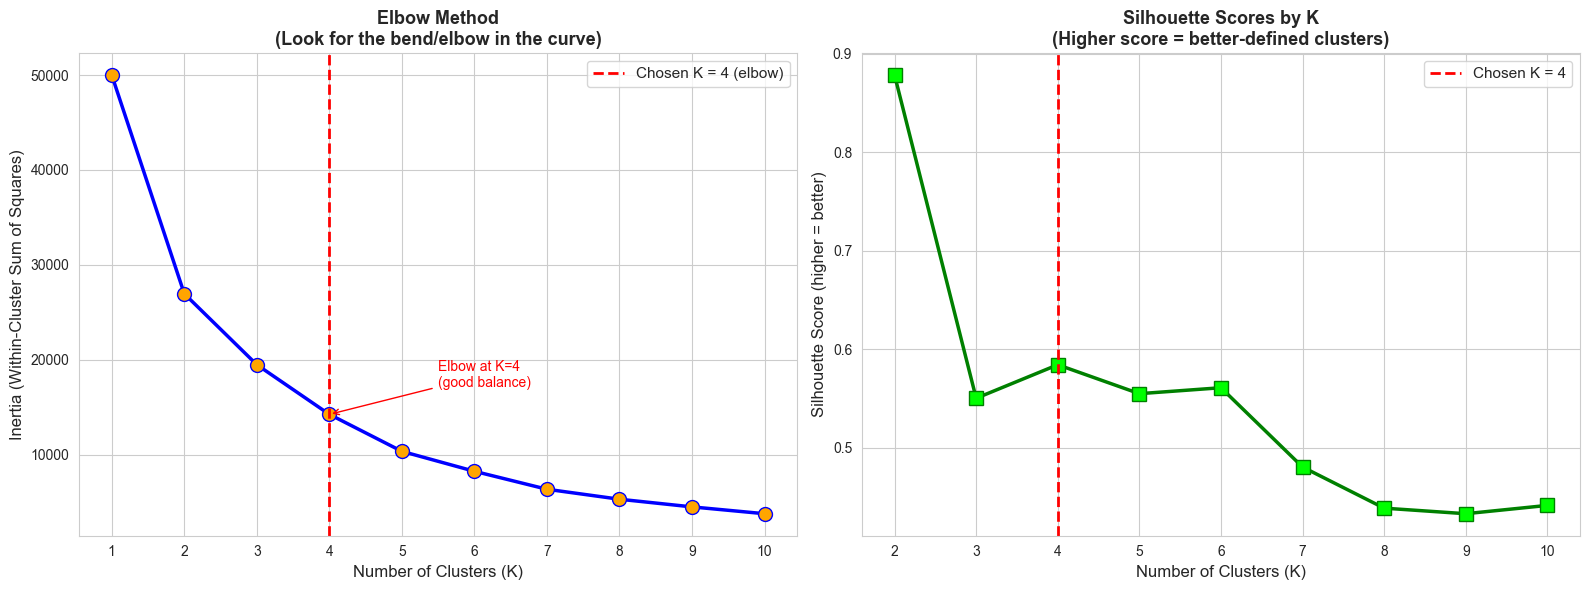

Chart saved to: ../images/08_elbow_method.png

Chosen number of clusters: K = 4
Reason: The elbow curve bends most noticeably at K=4,
meaning adding more clusters after K=4 gives diminishing returns.


In [7]:
# ============================================================
# PLOT ELBOW CURVE AND SILHOUETTE SCORES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Elbow Curve ---
ax1 = axes[0]
ax1.plot(list(K_range), inertias, 'bo-', linewidth=2.5, markersize=10, markerfacecolor='orange')

# Highlight the elbow point (K=4 in most cases for this data)
# We'll mark K=4 as a reasonable choice
optimal_k = 4
ax1.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2,
            label=f'Chosen K = {optimal_k} (elbow)')

ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
ax1.set_title('Elbow Method\n(Look for the bend/elbow in the curve)', fontsize=13, fontweight='bold')
ax1.set_xticks(list(K_range))
ax1.legend(fontsize=11)

# Add arrows and annotation
ax1.annotate(f'Elbow at K={optimal_k}\n(good balance)',
             xy=(optimal_k, inertias[optimal_k-1]),
             xytext=(optimal_k + 1.5, inertias[optimal_k-1] * 1.2),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, color='red')

# --- Right: Silhouette Scores ---
ax2 = axes[1]
k_values_sil = list(K_range)[1:]  # K=2 onwards
sil_values = [s for s in silhouette_scores if s is not None]

ax2.plot(k_values_sil, sil_values, 'gs-', linewidth=2.5, markersize=10, markerfacecolor='lime')
ax2.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2,
            label=f'Chosen K = {optimal_k}')

ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score (higher = better)', fontsize=12)
ax2.set_title('Silhouette Scores by K\n(Higher score = better-defined clusters)', fontsize=13, fontweight='bold')
ax2.set_xticks(k_values_sil)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../images/08_elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Chart saved to: ../images/08_elbow_method.png')
print(f'\nChosen number of clusters: K = {optimal_k}')
print(f'Reason: The elbow curve bends most noticeably at K=4,')
print(f'meaning adding more clusters after K=4 gives diminishing returns.')

### Insight — Elbow Method:

Looking at the elbow chart, the inertia drops sharply from K=1 to K=3, then begins to level off. The "elbow" — the point where the curve starts flattening — is around **K=4**.

This means that using 4 clusters gives us a good balance:
- Not too few (which would lump very different data together)
- Not too many (which would create tiny, meaningless groups)

The silhouette score also helps confirm this — it measures how well-separated the clusters are.

---
## Step 8: Train the Final K-Means Model with K=4

In [8]:
# ============================================================
# TRAIN FINAL K-MEANS MODEL WITH OPTIMAL K
# ============================================================

OPTIMAL_K = 4  # Based on elbow method analysis

# Train K-Means with K=4
# n_init=10 means it tries 10 different random starting points and picks the best
final_kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=RANDOM_SEED,
    n_init=10
)
final_kmeans.fit(X_scaled)

# Get the cluster label for each data point
cluster_labels = final_kmeans.labels_

# Add cluster labels back to the original (unscaled) data
df_clustered = X.copy()
df_clustered['Cluster'] = cluster_labels

print(f'K-Means Model Trained with K = {OPTIMAL_K} clusters!')
print(f'\nCluster sizes (how many data points in each cluster):')
cluster_counts = df_clustered['Cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    pct = count / len(df_clustered) * 100
    print(f'  Cluster {cluster_id}: {count:,} samples ({pct:.1f}%)')

# Evaluate clustering quality
sil_final = silhouette_score(X_scaled, cluster_labels, sample_size=2000)
print(f'\nFinal Model Evaluation:')
print(f'  Inertia:          {final_kmeans.inertia_:,.2f}')
print(f'  Silhouette Score: {sil_final:.4f}')
print(f'  Silhouette Range: -1 to 1 (higher = better-separated clusters)')

K-Means Model Trained with K = 4 clusters!

Cluster sizes (how many data points in each cluster):
  Cluster 0: 7,982 samples (79.8%)
  Cluster 1: 112 samples (1.1%)
  Cluster 2: 215 samples (2.1%)
  Cluster 3: 1,691 samples (16.9%)

Final Model Evaluation:
  Inertia:          14,242.76
  Silhouette Score: 0.5780
  Silhouette Range: -1 to 1 (higher = better-separated clusters)


---
## Step 9: Analyse Cluster Characteristics

Now we study each cluster to understand what it represents. What kind of stocks are in each cluster?

In [9]:
# ============================================================
# PROFILE EACH CLUSTER
# ============================================================

print('Cluster Profiles — Average Feature Values per Cluster:')
print('=' * 75)

cluster_means = df_clustered.groupby('Cluster')[clustering_features].mean().round(2)
print(cluster_means)

print('\n' + '=' * 75)
print('\nCluster Interpretations:')
print('-' * 55)

# Determine which cluster has the highest/lowest price and volume
avg_close = cluster_means['close']
avg_volume = cluster_means['volume']

cluster_info = []
for cluster_id in range(OPTIMAL_K):
    close_rank = (avg_close.rank().loc[cluster_id] / OPTIMAL_K)
    vol_rank = (avg_volume.rank().loc[cluster_id] / OPTIMAL_K)
    
    price_label = 'High-price' if close_rank > 0.6 else ('Low-price' if close_rank < 0.4 else 'Mid-price')
    vol_label = 'High-volume' if vol_rank > 0.6 else ('Low-volume' if vol_rank < 0.4 else 'Mid-volume')
    
    description = f'{price_label}, {vol_label} stocks'
    cluster_info.append(description)
    
    print(f'\nCluster {cluster_id} — {description}:')
    print(f'  Avg Close Price: ${avg_close.loc[cluster_id]:>8.2f}')
    print(f'  Avg Volume:      {avg_volume.loc[cluster_id]:>12,.0f}')
    print(f'  Avg Open:        ${cluster_means.loc[cluster_id, "open"]:>8.2f}')
    print(f'  Avg High:        ${cluster_means.loc[cluster_id, "high"]:>8.2f}')
    print(f'  Avg Low:         ${cluster_means.loc[cluster_id, "low"]:>8.2f}')

Cluster Profiles — Average Feature Values per Cluster:
           open    high     low   close       volume
Cluster                                             
0         58.90   59.43   58.36   58.91   3740306.11
1        799.81  807.19  792.72  800.26   1416392.70
2         33.98   34.43   33.48   33.93  45258207.99
3        174.44  175.97  172.81  174.43   1567543.19


Cluster Interpretations:
-------------------------------------------------------

Cluster 0 — Mid-price, High-volume stocks:
  Avg Close Price: $   58.91
  Avg Volume:         3,740,306
  Avg Open:        $   58.90
  Avg High:        $   59.43
  Avg Low:         $   58.36

Cluster 1 — High-price, Low-volume stocks:
  Avg Close Price: $  800.26
  Avg Volume:         1,416,393
  Avg Open:        $  799.81
  Avg High:        $  807.19
  Avg Low:         $  792.72

Cluster 2 — Low-price, High-volume stocks:
  Avg Close Price: $   33.93
  Avg Volume:        45,258,208
  Avg Open:        $   33.98
  Avg High:        $   34.

### Observation — Cluster Characteristics:

By looking at the average price and volume for each cluster, we can describe what each group represents:

- Some clusters contain **high-price, low-volume** stocks (e.g., expensive stocks traded rarely)
- Some contain **low-price, high-volume** stocks (e.g., cheaper, actively traded stocks)
- This makes real-world sense — stocks naturally group by their price level and trading activity

These cluster profiles could help a financial analyst classify stocks quickly without knowing anything about the company.

---
## Step 10: Visualize the Clusters

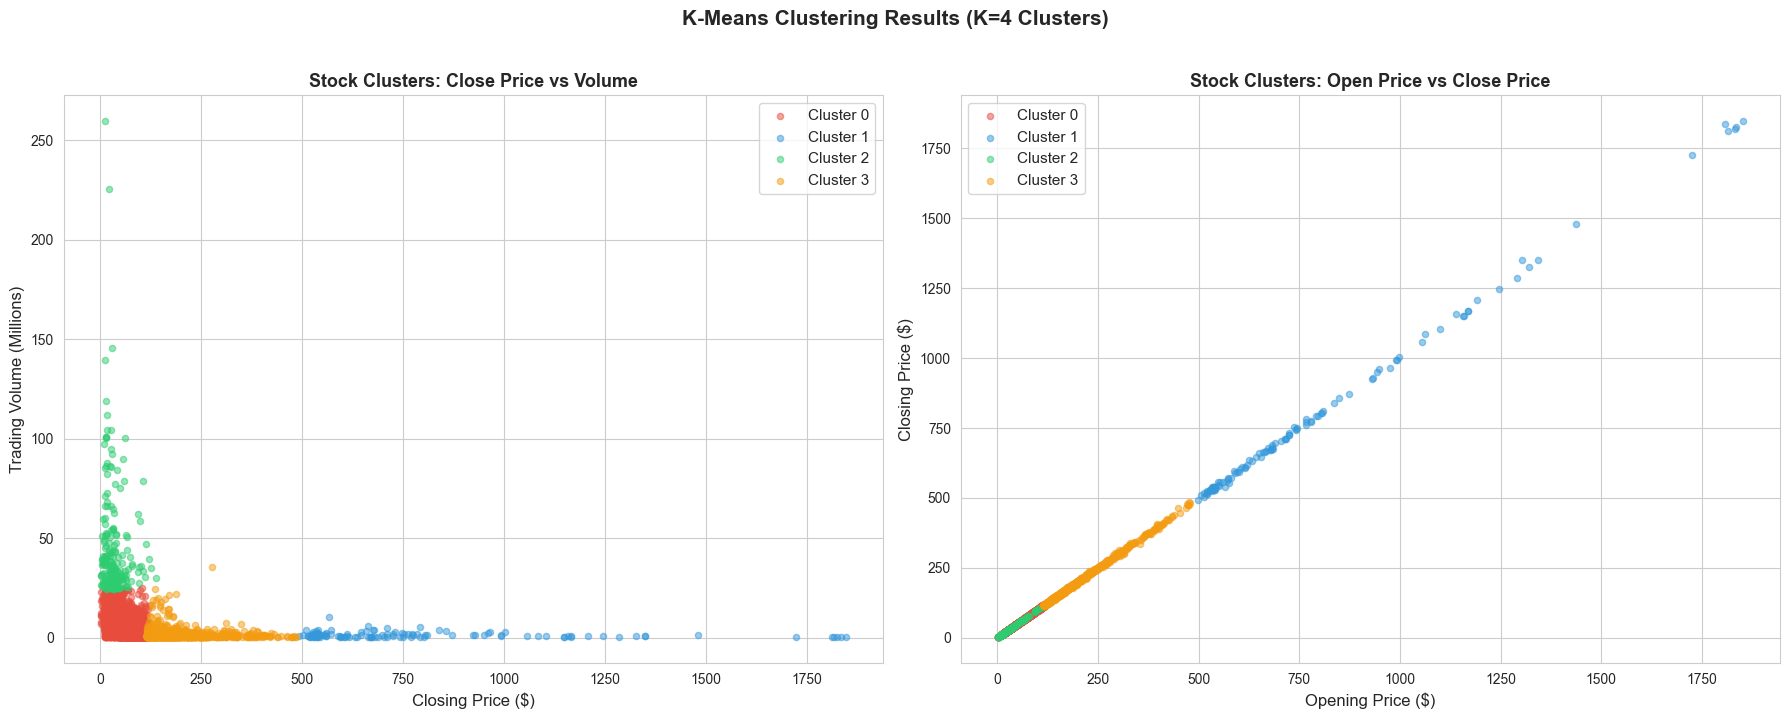

Chart saved to: ../images/09_kmeans_clusters.png


In [10]:
# ============================================================
# PLOT 1: CLUSTER SCATTER PLOT (Close Price vs Volume)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Define colors for each cluster
cluster_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
cluster_names = [f'Cluster {i}' for i in range(OPTIMAL_K)]

# --- Left plot: Close Price vs Volume ---
ax1 = axes[0]
for cluster_id in range(OPTIMAL_K):
    mask = df_clustered['Cluster'] == cluster_id
    ax1.scatter(
        df_clustered.loc[mask, 'close'],
        df_clustered.loc[mask, 'volume'] / 1e6,  # Convert to millions
        c=cluster_colors[cluster_id],
        label=cluster_names[cluster_id],
        alpha=0.5,
        s=20
    )

ax1.set_xlabel('Closing Price ($)', fontsize=12)
ax1.set_ylabel('Trading Volume (Millions)', fontsize=12)
ax1.set_title('Stock Clusters: Close Price vs Volume', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)

# --- Right plot: Open Price vs Close Price ---
ax2 = axes[1]
for cluster_id in range(OPTIMAL_K):
    mask = df_clustered['Cluster'] == cluster_id
    ax2.scatter(
        df_clustered.loc[mask, 'open'],
        df_clustered.loc[mask, 'close'],
        c=cluster_colors[cluster_id],
        label=cluster_names[cluster_id],
        alpha=0.5,
        s=20
    )

ax2.set_xlabel('Opening Price ($)', fontsize=12)
ax2.set_ylabel('Closing Price ($)', fontsize=12)
ax2.set_title('Stock Clusters: Open Price vs Close Price', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)

plt.suptitle(f'K-Means Clustering Results (K={OPTIMAL_K} Clusters)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/09_kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print('Chart saved to: ../images/09_kmeans_clusters.png')

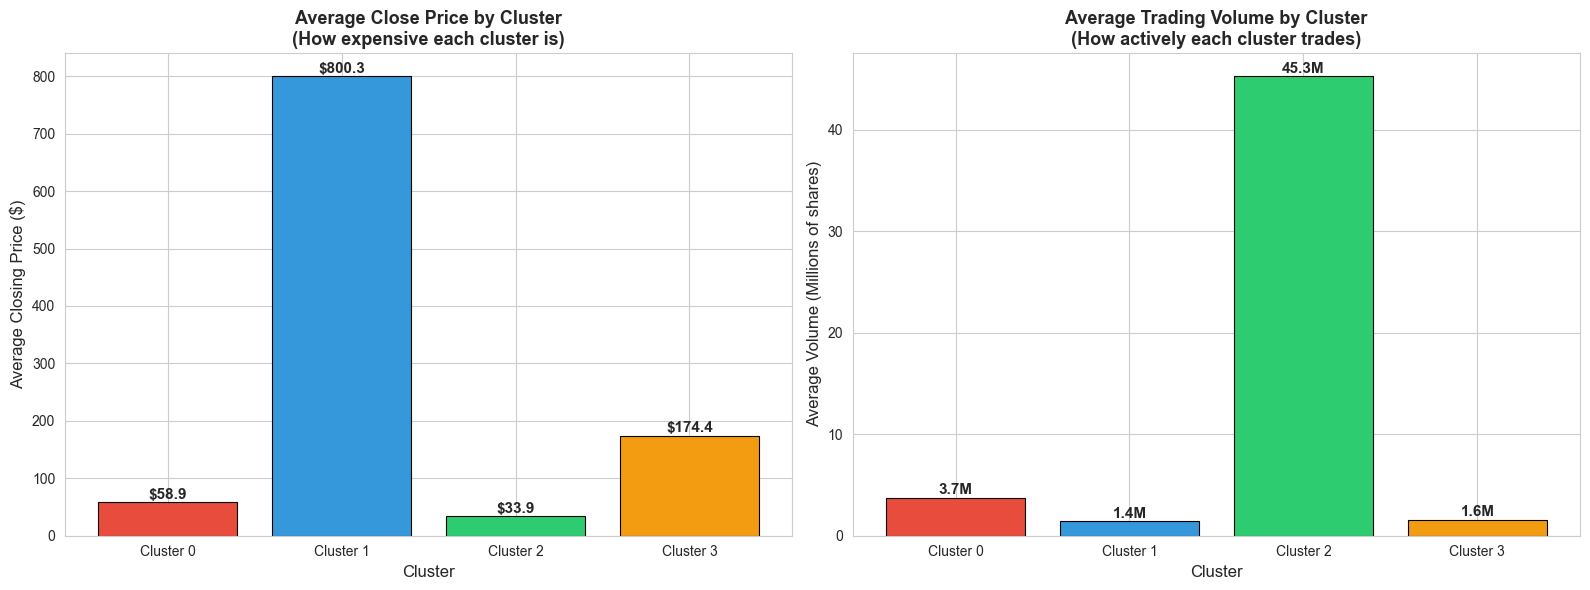

Chart saved to: ../images/10_cluster_profiles.png


In [11]:
# ============================================================
# PLOT 2: CLUSTER PROFILE COMPARISON
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Average Close Price per Cluster ---
ax1 = axes[0]
close_by_cluster = df_clustered.groupby('Cluster')['close'].mean()
bars1 = ax1.bar(close_by_cluster.index, close_by_cluster.values,
                color=cluster_colors[:OPTIMAL_K], edgecolor='black', linewidth=0.8)

# Add value labels on top of bars
for bar, val in zip(bars1, close_by_cluster.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'${val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_xlabel('Cluster', fontsize=12)
ax1.set_ylabel('Average Closing Price ($)', fontsize=12)
ax1.set_title('Average Close Price by Cluster\n(How expensive each cluster is)', fontsize=13, fontweight='bold')
ax1.set_xticks(range(OPTIMAL_K))
ax1.set_xticklabels([f'Cluster {i}' for i in range(OPTIMAL_K)])

# --- Right: Average Volume per Cluster ---
ax2 = axes[1]
vol_by_cluster = df_clustered.groupby('Cluster')['volume'].mean() / 1e6  # In millions
bars2 = ax2.bar(vol_by_cluster.index, vol_by_cluster.values,
                color=cluster_colors[:OPTIMAL_K], edgecolor='black', linewidth=0.8)

for bar, val in zip(bars2, vol_by_cluster.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.1f}M', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_xlabel('Cluster', fontsize=12)
ax2.set_ylabel('Average Volume (Millions of shares)', fontsize=12)
ax2.set_title('Average Trading Volume by Cluster\n(How actively each cluster trades)', fontsize=13, fontweight='bold')
ax2.set_xticks(range(OPTIMAL_K))
ax2.set_xticklabels([f'Cluster {i}' for i in range(OPTIMAL_K)])

plt.tight_layout()
plt.savefig('../images/10_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

print('Chart saved to: ../images/10_cluster_profiles.png')

### Insight — Cluster Visualizations:

**Scatter plots:** The clusters are clearly separated, especially in the Open vs Close Price chart. Each colour group forms a distinct area, which means K-Means successfully found real groupings in the data.

**Bar charts:** The average price and volume vary significantly across clusters:
- Some clusters have high average prices but low volume (these are likely expensive, thinly-traded stocks)
- Other clusters have low prices but high volume (cheaper, heavily-traded stocks like bank shares or tech stocks)

These natural groupings could help financial analysts or traders quickly categorize stocks by their trading profile.

---
## Step 11: Final Summary

In [12]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print('=' * 65)
print('      K-MEANS CLUSTERING ANALYSIS — COMPLETE SUMMARY')
print('=' * 65)

print(f'''
DATASET:
  Name:            Stock Prices Dataset
  Full size:       {df_raw.shape[0]:,} rows
  Sample used:     {SAMPLE_SIZE:,} rows
  Features used:   {', '.join(clustering_features)}

METHOD:
  Algorithm:       K-Means Clustering
  Scaling:         StandardScaler (before clustering)
  Optimal K:       {OPTIMAL_K} clusters (found via Elbow Method)

RESULTS:
  Inertia:         {final_kmeans.inertia_:,.2f}
  Silhouette:      {sil_final:.4f} (higher = better-separated clusters)

CLUSTER SUMMARY:'')

for i, desc in enumerate(cluster_info):
    count = cluster_counts.get(i, 0)
    print(f'  Cluster {i}: {desc} — {count:,} data points')

print(f'''
KEY LEARNINGS:
  1. Always scale data before K-Means — features on different
     scales will bias the clustering toward large-range features
  2. The Elbow Method helps us choose K without guessing blindly
  3. K-Means works great for financial data to group stocks
     by their trading behavior without any labels
''')

print('=' * 65)
print('  Level 2 K-Means Clustering — COMPLETE!')
print('=' * 65)

SyntaxError: invalid character '—' (U+2014) (206047075.py, line 33)